# Notebook for Fitting PDFs with diffpy.cmi

## Import Functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from diffpy_fitting import FitConfig, fit_one, fit_batch, results_to_dataframe, plot_series, build_reference, fit_dgr_batch

%matplotlib widget

## Set Path

In [2]:
file_path = Path(r"C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\BTO400nmS3_360Kre4\output")

## Config Variables

In [11]:
cfg = FitConfig(
    # ── Required ──────────────────────────────────────────────
    cif_path = f"{file_path}/BaTiO3_tetragonal.cif",   # path to your CIF file

    # ── PDF r-range ───────────────────────────────────────────
    rmin  = 10.0,   # Å  — lower bound of fit range
    rmax  = 30.0,   # Å  — upper bound of fit range
    rstep = 0.01,   # Å  — grid spacing

    # ── Q-range ───────────────────────────────────────────────
    qmax = 12.0,    # Å⁻¹ — max Q used in PDF calculation
    qmin = 0.3,     # Å⁻¹ — min Q used in PDF calculation

    # ── Structure ─────────────────────────────────────────────
    space_group = "P4mm",   # space group for constrainAsSpaceGroup

    # ── Initial parameter guesses ─────────────────────────────
    scale_i  = 0.5,    # overall scale factor
    uiso_i   = 0.005,  # Å²  — starting Uiso for all sites
    delta2_i = 1.7,    # Å²  — correlated motion parameter
    qdamp_i  = 0.04,   # Å⁻¹ — instrumental dampening
    qbroad_i = 0.07,   # Å⁻¹ — instrumental broadening

    # ── Instrumental toggles ──────────────────────────────────
    fix_qdamp  = True,   # True = pin Qdamp even in full fits
    fix_qbroad = True,   # True = pin Qbroad even in full fits

    # ── Parameter bounds for least_squares ───────────────────
    param_bounds = {
        "s1":           (1e-4, 10.0),
        "Delta2":       (0.0,  50.0),
        "Calib_Qdamp":  (0.0,  0.15),
        "Calib_Qbroad": (0.0,  0.10),
        "a":            (3.9, 4.2),
        "c":            (3.9, 4.2),
        "_adp_default": (1e-5, 0.1),  # applies to all ADP_ parameters
    },

    # ── Reduced-mode pinning ──────────────────────────────────
    pinned_in_reduced = ["Delta2", "Calib_Qdamp", "Calib_Qbroad"],

    # ── Output ────────────────────────────────────────────────
    save_outputs = False,    # False = no files written (good for exploring)
    resdir = None,          # Path to save .res files; defaults to data_dir/res
    fitdir = None,          # Path to save .fit files; defaults to data_dir/fit
    figdir = None,          # Path to save figures;   defaults to data_dir/fig

    # ── Performance ───────────────────────────────────────────
    run_parallel = True,    # use multiprocessing for PDF calculation
)

## Fit One File

Fitting BaTiO3_-80.0_gr.gr [full]
    scale          Rw = 0.3484
    + lat          Rw = 0.2311
    + adp          Rw = 0.1726
    + Delta2       Rw = 0.1721
    final polish   Rw = 0.1721


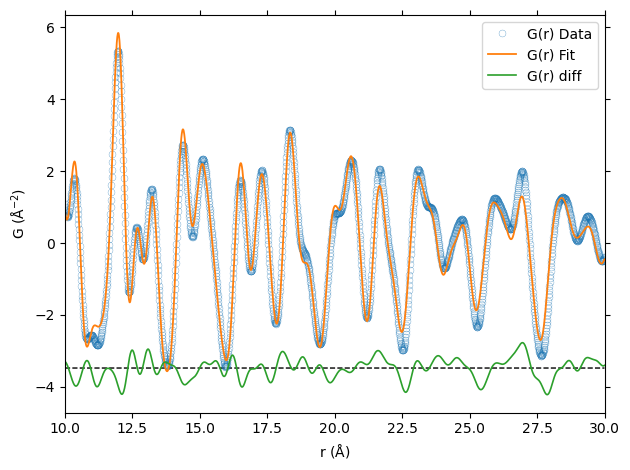

In [4]:
result = fit_one(f"{file_path}/BaTiO3_-80.0_gr.gr", cfg)
result.plot()

In [5]:
result.params

{'s1': np.float64(0.6414492849065155),
 'a': 4.00886476837566,
 'c': 4.0339874469409995,
 'ADP_U11_0': np.float64(0.0068946767751225805),
 'ADP_U33_0': np.float64(0.008478244724530265),
 'ADP_U11_1': np.float64(0.00562884141461045),
 'ADP_U33_1': np.float64(0.024591886311346914),
 'ADP_U11_2': np.float64(0.000965331137579605),
 'ADP_U33_2': np.float64(1.000111396692023e-05),
 'ADP_U11_3': np.float64(0.03153405316335667),
 'ADP_U22_3': np.float64(0.03153405316335667),
 'ADP_U33_3': np.float64(0.03153405316335667),
 'Delta2': 0.0001759410784790914,
 'Calib_Qdamp': 0.04,
 'Calib_Qbroad': 0.07}

## Batch Fit

Found 5 file(s): 2 full, 3 reduced.

=== Pass 1: Full-mode refinements ===
  [1/5] BaTiO3_-2.0_gr.gr... Rw = 0.1716
  [2/5] BaTiO3_-80.0_gr.gr... Rw = 0.1721

Reference values (averaged over full fits):
  Delta2         = 0.000080
  Calib_Qdamp    = 0.040000
  Calib_Qbroad   = 0.070000

=== Pass 2: Reduced-mode refinements ===
  [3/5] BaTiO3_1.0_gr.gr... Rw = 0.1723
  [4/5] BaTiO3_10.0_gr.gr... 

c:\Users\lheald\AppData\Local\miniconda3\envs\diffpy\Lib\site-packages\diffpy\srfit\fitbase\fitresults.py:205: RuntimeWarning: divide by zero encountered in divide
  self.cov = numpy.dot(vh.T.conj() / s**2, vh)
c:\Users\lheald\AppData\Local\miniconda3\envs\diffpy\Lib\site-packages\diffpy\srfit\fitbase\fitresults.py:205: RuntimeWarning: invalid value encountered in divide
  self.cov = numpy.dot(vh.T.conj() / s**2, vh)
c:\Users\lheald\AppData\Local\miniconda3\envs\diffpy\Lib\site-packages\diffpy\srfit\fitbase\fitresults.py:205: RuntimeWarning: invalid value encountered in dot
  self.cov = numpy.dot(vh.T.conj() / s**2, vh)


Rw = 0.1723
  [5/5] BaTiO3_200.0_gr.gr... Rw = 0.1719


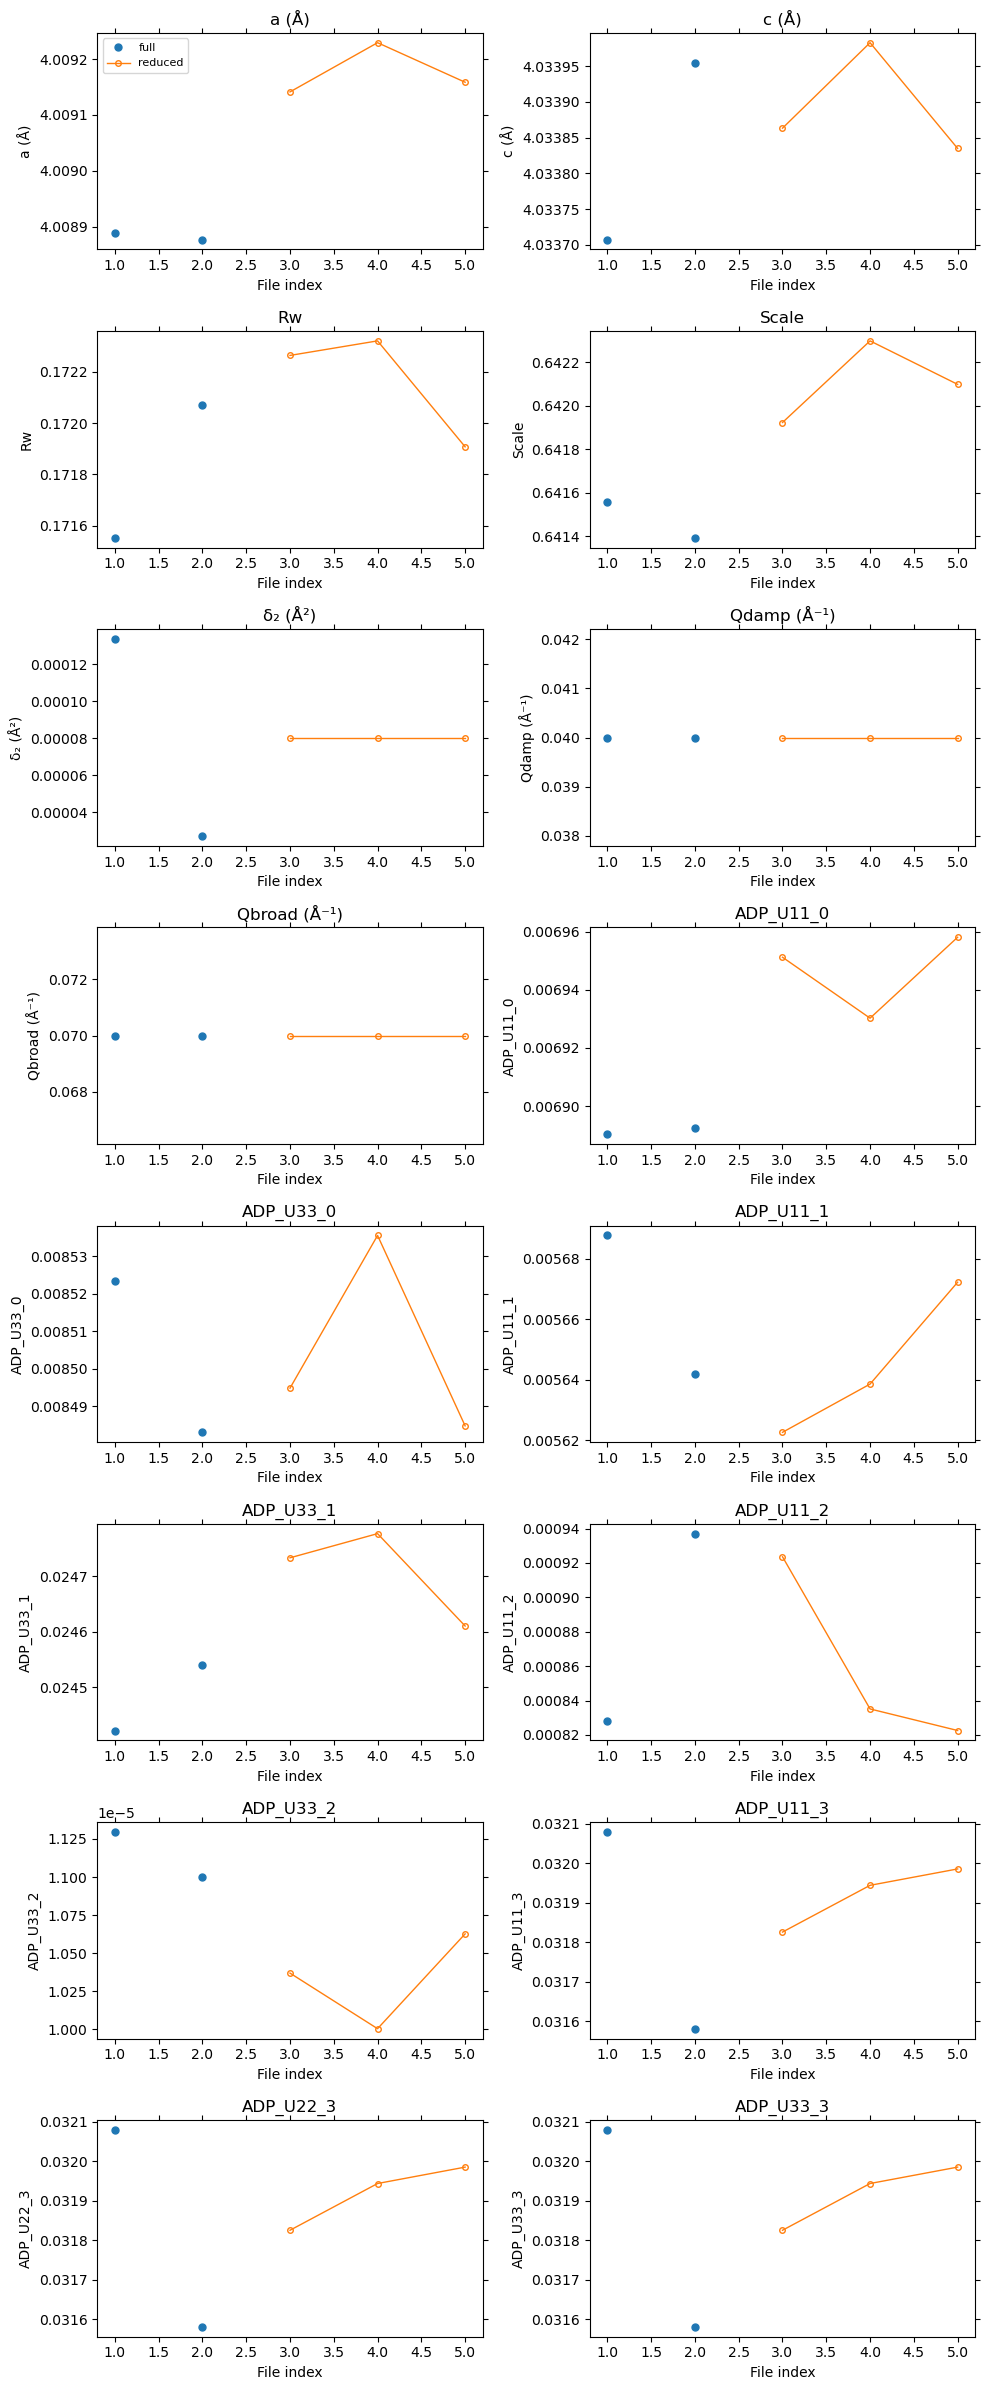

In [6]:
results = fit_batch(f"{file_path}/BaTiO3_*.gr", cfg, full_indices=(0, 2))
df = results_to_dataframe(results)
plot_series(df)

## Fitting dG(r)s

Building reference from 2 file(s):
  BaTiO3_-80.0_gr.gr
  BaTiO3_-2.0_gr.gr
Full-fitting averaged reference G(r)...
Fitting tmp0192n8zn.gr [full]
    scale          Rw = 0.3481
    + lat          Rw = 0.2313
    + adp          Rw = 0.1684
    + Delta2       Rw = 0.1679
    final polish   Rw = 0.1679
  Reference Rw = 0.1679
Excluded 2 reference file(s) from batch.

=== ΔG fits: 3 file(s) ===
  [1/3] BaTiO3_1.0_gr.gr... Rw = 0.6018
  [2/3] BaTiO3_10.0_gr.gr... 

c:\Users\lheald\AppData\Local\miniconda3\envs\diffpy\Lib\site-packages\diffpy\srfit\fitbase\fitresults.py:205: RuntimeWarning: divide by zero encountered in divide
  self.cov = numpy.dot(vh.T.conj() / s**2, vh)
c:\Users\lheald\AppData\Local\miniconda3\envs\diffpy\Lib\site-packages\diffpy\srfit\fitbase\fitresults.py:205: RuntimeWarning: invalid value encountered in divide
  self.cov = numpy.dot(vh.T.conj() / s**2, vh)
c:\Users\lheald\AppData\Local\miniconda3\envs\diffpy\Lib\site-packages\diffpy\srfit\fitbase\fitresults.py:205: RuntimeWarning: invalid value encountered in dot
  self.cov = numpy.dot(vh.T.conj() / s**2, vh)


Rw = 0.4631
  [3/3] BaTiO3_200.0_gr.gr... Rw = 0.5456


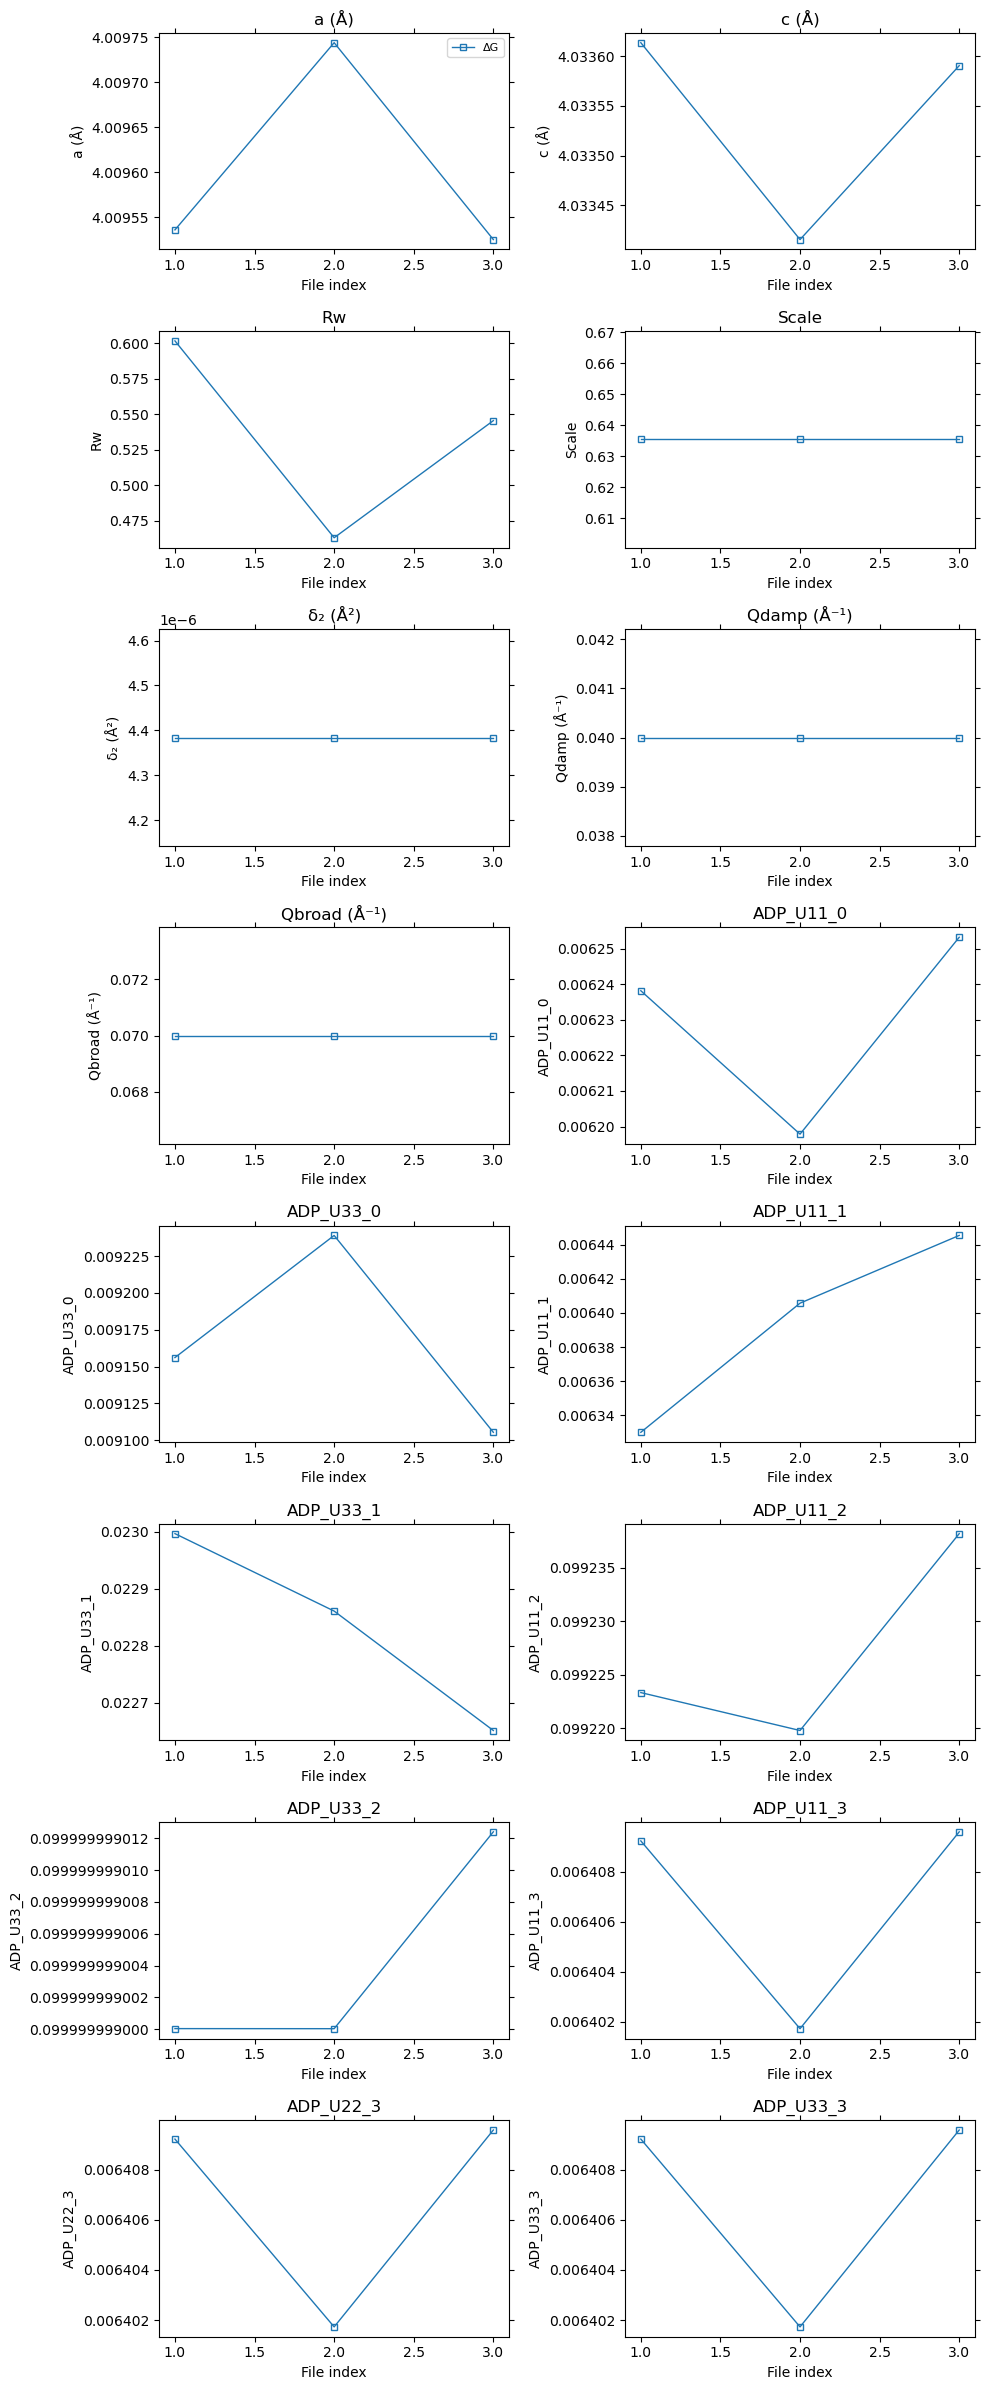

In [12]:
# Build reference from pre-t0 files (averages them, fits the average once)
ref = build_reference([f"{file_path}/BaTiO3_-80.0_gr.gr", f"{file_path}/BaTiO3_-2.0_gr.gr"], cfg)

# Fit ΔG for the full time series
results = fit_dgr_batch(f"{file_path}/BaTiO3_*.gr", ref, cfg, pin_scale=True)

df = results_to_dataframe(results)
plot_series(df)

In [13]:
df

,file,rw,mode,s1,a,c,ADP_U11_0,ADP_U33_0,ADP_U11_1,ADP_U33_1,ADP_U11_2,ADP_U33_2,ADP_U11_3,ADP_U22_3,ADP_U33_3,Delta2,Calib_Qdamp,Calib_Qbroad
0,BaTiO3_1.0_gr.gr,0.601820,dgr,0.635488,4.009536,4.033614,0.006238,0.009156,0.006330,0.022997,0.099223,0.1,0.006409,0.006409,0.006409,0.000004,0.04,0.07
1,BaTiO3_10.0_gr.gr,0.463074,dgr,0.635488,4.009744,4.033416,0.006198,0.009239,0.006406,0.022861,0.099220,0.1,0.006402,0.006402,0.006402,0.000004,0.04,0.07
2,BaTiO3_200.0_gr.gr,0.545616,dgr,0.635488,4.009525,4.033590,0.006253,0.009105,0.006445,0.022651,0.099238,0.1,0.006410,0.006410,0.006410,0.000004,0.04,0.07


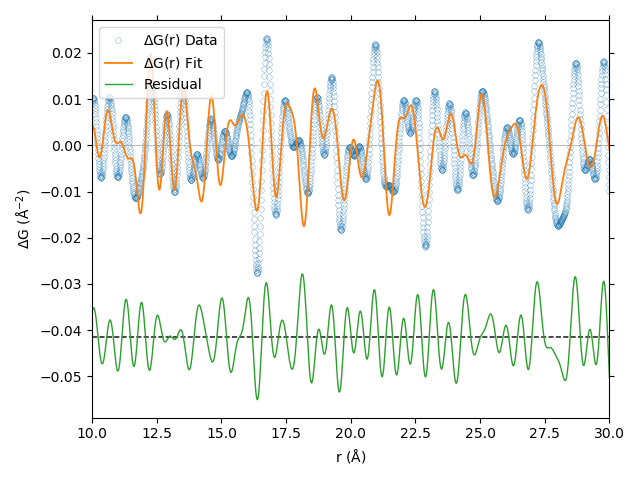

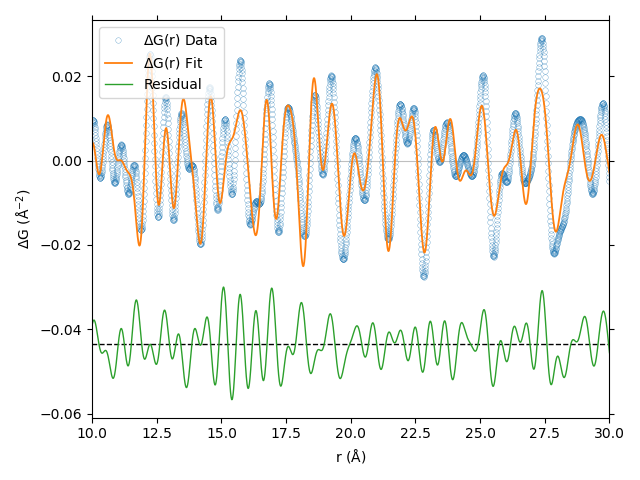

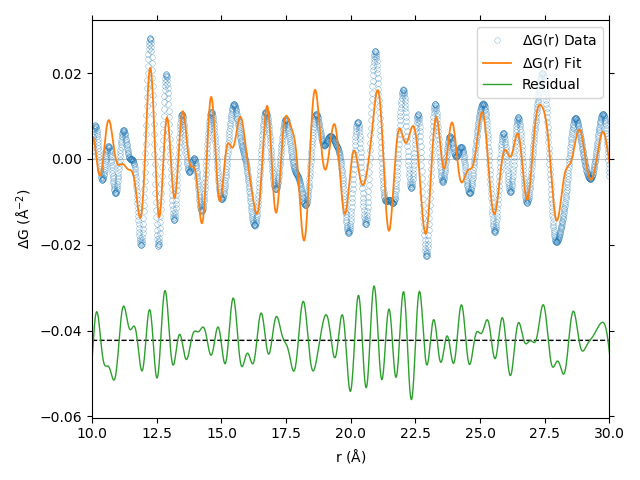

In [14]:
for r in results:
    r.plot()
    plt.show()